In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import glob
import os
warnings.filterwarnings('ignore')

In [56]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [57]:
while not os.path.isdir(os.path.join(os.getcwd(), 'data')):
    os.chdir("../") # set cwd to root dir

In [58]:
def get_filtered_strides_count(is_fatigue):
    protocol = "fatigue" if is_fatigue else "control"
    stride_file_names = glob.glob(f"data/DUO-GAIT/processed/OG_st_{protocol}/**/*core_params.csv") # get all files with exact stride information

    count = 0
    for file_name in stride_file_names:
        foot_df = pd.read_csv(file_name)
        foot_df = foot_df[foot_df['is_outlier'] == False].reset_index(drop=True) # remove outliers
        count += len(foot_df)

    return count

In [59]:
num_control = get_filtered_strides_count(0)
num_fatigue = get_filtered_strides_count(1)

Text(0, 0.5, 'Counts')

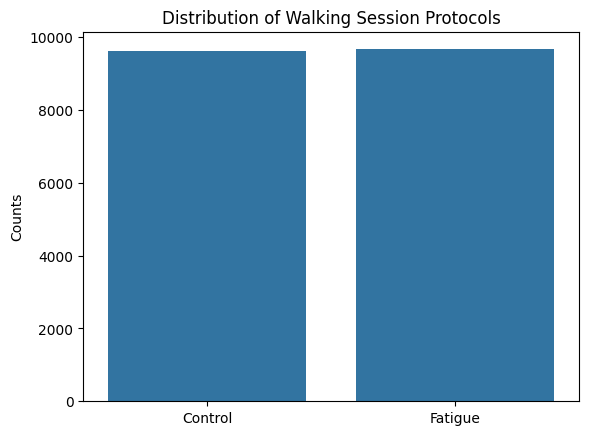

In [60]:
sns.barplot(x=['Control', 'Fatigue'], y=[num_control, num_fatigue])
plt.title('Distribution of Walking Session Protocols')
plt.ylabel('Counts')

Balanced dataset between control and fatigue walking sessions.